# All-BA 2023 load-forecast validation

Compare packaged TELL forecasts with cleaned EIA-930 actual load for every BA in the
2023 validation set. The complete metric table and three representative scatter plots
show both overall coverage and individual forecast behavior.

**Inputs:** Historical BA forecasts, bundled cleaned 2023 observations, and validation metadata.

**Requirements:** The repository environment and the historical archive extracted into `data_inputs/`.

**Outputs:** Inline coverage, metrics, and scatter plots; no standalone files.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).

Direct total MISO is one BA here. The separate
[MISO subregion validation](miso_subregion_load_forecast_validation.ipynb) compares that
forecast with the six-subregion sum. See the [BA coverage guide](../../README.md#coverage)
for the full released set.


## Setup

Run this notebook from `notebooks/validation`. Once the historical archive is
extracted, this validation runs offline.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Define the validation set

The packaged metadata is the authoritative list for this check. It follows the
TELL BA set while omitting entities without usable cleaned 2023 actual-load data.

AEC and NSB have packaged modeled load but are excluded here because usable cleaned actuals are not included for them.

In [2]:
VALIDATION_YEAR = 2023
EXPECTED_HOURS = 8_760

ba_metadata = pd.read_csv(
    "../../data_inputs/validation/load_forecast/ba_2023_validation_metadata.csv",
    dtype={
        "BA_CODE": str,
        "BA_ID": str,
        "BA_NAME": str,
    },
)

required_metadata_columns = {"BA_CODE", "BA_ID", "BA_NAME"}
missing_columns = required_metadata_columns - set(ba_metadata.columns)
if missing_columns:
    raise KeyError(f"BA metadata is missing {sorted(missing_columns)}.")
if ba_metadata["BA_CODE"].duplicated().any():
    raise AssertionError("The BA validation metadata contains duplicate BA codes.")

print(f"Validation set: {len(ba_metadata)} BAs; first five shown.")
with pd.option_context("display.max_colwidth", None):
    display(ba_metadata.head())

Validation set: 58 BAs; first five shown.


,BA_CODE,BA_ID,BA_NAME
0,AECI,924,"Associated Electric Cooperative, Inc."
1,AVA,20169,Avista Corporation
2,AZPS,803,Arizona Public Service Company
3,BANC,16534,Balancing Authority of Northern California
4,BPAT,1738,Bonneville Power Administration


## Step 2: Align actual and forecast load

For each BA, timestamps are parsed as UTC and the 2023 rows are joined one to one.
The checks below require all 8,760 non-leap-year timestamps for every BA; metrics use the cleaned, non-missing subset.


In [3]:
validation_frames = []

for ba in ba_metadata.itertuples(index=False):
    # Read cleaned observations and keep the validation year.
    actual_path = f"../../data_inputs/load_actuals/cleaned_2023/{ba.BA_CODE}_cleaned_load_2023.csv"
    actual = pd.read_csv(
        actual_path,
        usecols=["time_utc", "load_actual_mw_clean"],
    )
    actual["time_utc"] = pd.to_datetime(actual["time_utc"], utc=True)
    actual_in_year = actual["time_utc"].dt.year.eq(VALIDATION_YEAR)
    actual = actual.loc[actual_in_year].copy()

    # Read the forecast for the same BA and year.
    forecast_path = (
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_load/"
        f"{ba.BA_CODE}_wtk_bchrrr_nsrdb_2007_2023_load.csv"
    )
    forecast = pd.read_csv(
        forecast_path,
        usecols=["time_utc", "load_mw"],
    )
    forecast["time_utc"] = pd.to_datetime(forecast["time_utc"], utc=True)
    forecast_in_year = forecast["time_utc"].dt.year.eq(VALIDATION_YEAR)
    forecast = forecast.loc[forecast_in_year].copy()
    forecast = forecast.rename(columns={"load_mw": "forecast_load_mw"})

    actual_has_duplicates = actual["time_utc"].duplicated().any()
    forecast_has_duplicates = forecast["time_utc"].duplicated().any()
    if actual_has_duplicates or forecast_has_duplicates:
        raise AssertionError(f"Duplicate 2023 timestamps for {ba.BA_CODE}.")
    if len(actual) != EXPECTED_HOURS or len(forecast) != EXPECTED_HOURS:
        raise AssertionError(f"Incomplete 2023 coverage for {ba.BA_CODE}.")

    # Join the two series on UTC time, then record the BA identity.
    aligned = actual.merge(
        forecast,
        on="time_utc",
        how="inner",
        validate="one_to_one",
    )
    if len(aligned) != EXPECTED_HOURS:
        raise AssertionError(f"Actual and forecast timestamps do not align for {ba.BA_CODE}.")
    aligned.insert(0, "BA_NAME", ba.BA_NAME)
    aligned.insert(0, "BA_CODE", ba.BA_CODE)
    validation_frames.append(aligned)

validation = pd.concat(validation_frames, ignore_index=True)

coverage = validation.groupby("BA_CODE", as_index=False).agg(
    cleaned_hours=("load_actual_mw_clean", "count"),
)
if not coverage["cleaned_hours"].ge(8_000).all():
    raise AssertionError("Every BA must retain at least 8,000 cleaned validation hours.")
if "MISO_SUBREGION_SUM" in set(validation["BA_CODE"]):
    raise AssertionError(
        "The derived MISO sum belongs only in the focused MISO validation notebook."
    )

fewest_cleaned_hours = coverage["cleaned_hours"].min()
most_cleaned_hours = coverage["cleaned_hours"].max()
print(f"All {len(coverage)} BAs have {EXPECTED_HOURS:,} aligned timestamps.")
print(f"Usable cleaned observations per BA: {fewest_cleaned_hours:,} to {most_cleaned_hours:,}.")

All 58 BAs have 8,760 aligned timestamps.
Usable cleaned observations per BA: 8,110 to 8,760.


## Step 3: Calculate BA-level metrics

Error is forecast minus cleaned actual load. `NRMSE` is RMSE divided by mean
actual load; `MAPE` is stored as a fraction and displayed as a percentage. Lower MAE, RMSE, NRMSE, and MAPE
indicate closer agreement, while bias shows the signed mean error.


In [4]:
metric_rows = []

for ba_code, frame in validation.groupby("BA_CODE", sort=True):
    frame = frame.dropna(subset=["load_actual_mw_clean", "forecast_load_mw"])
    frame = frame.copy()
    actual = frame["load_actual_mw_clean"]
    forecast = frame["forecast_load_mw"]
    error = forecast - actual

    # Absolute and squared errors summarize forecast disagreement.
    absolute_error = error.abs()
    squared_error = np.square(error)
    mean_squared_error = np.mean(squared_error)
    rmse = float(np.sqrt(mean_squared_error))
    mean_actual = actual.mean()

    # Percentage errors use only hours with nonzero actual load.
    nonzero = actual.ne(0)
    absolute_percentage_error = error.loc[nonzero].abs() / actual.loc[nonzero].abs()

    # R-squared compares squared forecast error with observed variability.
    actual_deviation = actual - mean_actual
    squared_deviation = np.square(actual_deviation)
    r2 = float(1.0 - squared_error.sum() / squared_deviation.sum())

    metric_rows.append(
        {
            "BA_CODE": ba_code,
            "BA_NAME": frame["BA_NAME"].iloc[0],
            "hours_compared": len(frame),
            "MAE_MW": float(absolute_error.mean()),
            "RMSE_MW": rmse,
            "NRMSE_MEAN_ACTUAL": rmse / float(mean_actual),
            "MAPE": float(absolute_percentage_error.mean()),
            "R2": r2,
            "BIAS_MW": float(error.mean()),
        }
    )

metrics = pd.DataFrame(metric_rows)
metrics = metrics.sort_values("NRMSE_MEAN_ACTUAL")
metrics = metrics.reset_index(drop=True)
numeric_metrics = ["MAE_MW", "RMSE_MW", "NRMSE_MEAN_ACTUAL", "MAPE", "R2", "BIAS_MW"]
metric_values = metrics[numeric_metrics].to_numpy()
if len(metrics) != len(ba_metadata) or not np.isfinite(metric_values).all():
    raise AssertionError("The all-BA metric table is incomplete or contains non-finite values.")

# Format a display copy; retain the unrounded metrics for later calculations.
metrics_display = metrics.copy()
metrics_display["MAPE"] = metrics["MAPE"] * 100
metrics_display = metrics_display.rename(
    columns={
        "BA_CODE": "BA",
        "BA_NAME": "BA name",
        "hours_compared": "Hours compared",
        "MAE_MW": "MAE (MW)",
        "RMSE_MW": "RMSE (MW)",
        "BIAS_MW": "Bias (MW)",
        "NRMSE_MEAN_ACTUAL": "NRMSE (fraction)",
        "MAPE": "MAPE (%)",
        "R2": "R²",
    }
)
metrics_display = metrics_display.set_index("BA")
metrics_display = metrics_display.round(
    {
        "MAE (MW)": 1,
        "RMSE (MW)": 1,
        "Bias (MW)": 1,
        "NRMSE (fraction)": 3,
        "MAPE (%)": 2,
        "R²": 3,
    }
)
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.max_colwidth",
    None,
):
    display(metrics_display)

,BA name,Hours compared,MAE (MW),RMSE (MW),NRMSE (fraction),MAPE (%),R²,Bias (MW)
BA,,,,,,,,
MISO,"Midcontinent Independent System Operator, Inc.",8760,1475.6,1914.0,0.026,2.06,0.970,-320.4
PJM,"PJM Interconnection, LLC",8735,1787.0,2413.4,0.027,1.97,0.969,-341.1
TVA,Tennessee Valley Authority,8753,400.8,537.6,0.030,2.24,0.976,-21.4
MISO_0035,MISO subregion 0035,8760,252.7,324.6,0.032,2.51,0.959,-174.6
MISO_8910,MISO subregion 8910,8756,493.2,647.3,0.033,2.49,0.975,-148.9
DUK,Duke Energy Carolinas,8760,296.4,391.0,0.033,2.48,0.974,-138.4
NEVP,Nevada Power Company,8760,113.7,145.0,0.033,2.60,0.982,-62.3
SOCO,"Southern Company Services, Inc. - Trans",8758,702.8,892.7,0.034,2.77,0.972,-284.8
MISO_0027,MISO subregion 0027,8760,445.0,616.2,0.035,2.59,0.941,-5.4


## Step 4: Plot representative forecasts

AECI, direct MISO, and SWPP provide three geographically and operationally
different examples. Each point is one 2023 hour; the diagonal is perfect agreement.


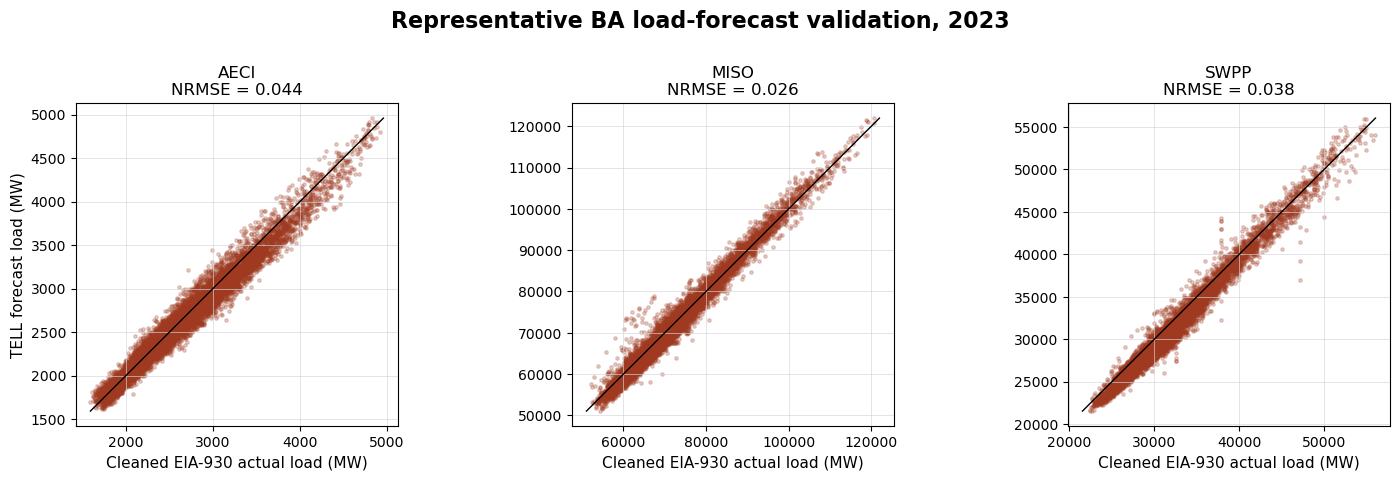

In [5]:
# Shared appearance for this notebook's figures.

REPRESENTATIVE_BAS = ["AECI", "MISO", "SWPP"]
if not set(REPRESENTATIVE_BAS).issubset(set(validation["BA_CODE"])):
    raise AssertionError("A representative BA is missing from the validation set.")

fig, axes = plt.subplots(1, len(REPRESENTATIVE_BAS), figsize=(15, 4.6))
for ax, ba_code in zip(axes, REPRESENTATIVE_BAS):
    ba_rows = validation["BA_CODE"].eq(ba_code)
    frame = validation.loc[ba_rows]
    actual = frame["load_actual_mw_clean"]
    forecast = frame["forecast_load_mw"]
    lower = min(actual.min(), forecast.min())
    upper = max(actual.max(), forecast.max())
    ba_metrics = metrics.loc[metrics["BA_CODE"].eq(ba_code)]
    row = ba_metrics.iloc[0]

    ax.scatter(
        actual,
        forecast,
        s=6,
        alpha=0.24,
        color="#9f3a20",
        rasterized=True,
    )
    ax.plot([lower, upper], [lower, upper], color="black", linewidth=1)
    ax.set_title(f"{ba_code}\nNRMSE = {row['NRMSE_MEAN_ACTUAL']:.3f}", fontsize=12)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Cleaned EIA-930 actual load (MW)")
    ax.grid(True)

axes[0].set_ylabel("TELL forecast load (MW)")
fig.suptitle("Representative BA load-forecast validation, 2023", y=1.02)
fig.tight_layout()
plt.show()

## Interpretation

The table provides the complete all-BA comparison. The representative panels are
diagnostic examples rather than a selected performance subset; conclusions about
the validation set should use the full metric table above.
